   store_id store_size location_type  promotion_type  is_weekend  is_festival  \
0        28      small    semi-urban       free_gift           1            0   
1         5     medium    semi-urban       free_gift           1            1   
2        13      small    semi-urban  loyalty_points           1            0   
3        17      small         urban       free_gift           1            0   
4        50     medium    semi-urban            bogo           0            0   

   competition_density  items_sold  year  month  day_of_week  is_month_end  
0                    5         224  2022      1            5             0  
1                    1         348  2022      1            5             0  
2                    6         249  2022      1            6             0  
3                    7         259  2022      1            6             0  
4                    3         277  2022      1            0             0  
Linear Regression RMSE: 27.073039093479675
Linear R

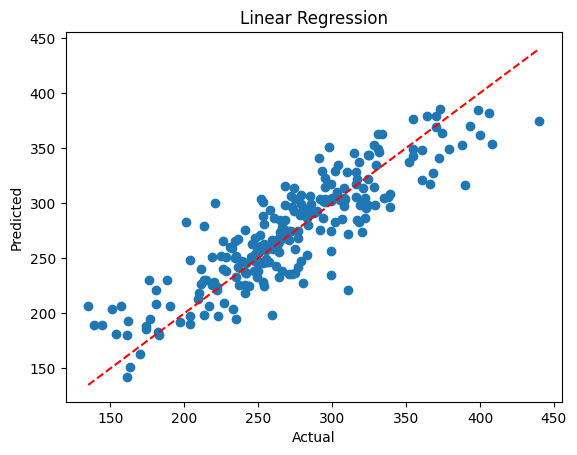

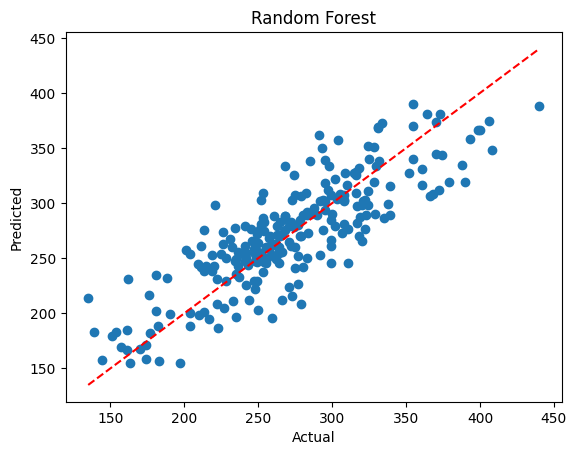

Top 5 Features:
 store_size_small       0.168388
is_festival            0.168287
location_type_urban    0.106535
day_of_week            0.089820
is_weekend             0.062113
dtype: float64


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("q3_retail_promotions.csv")

# -----------------------------
# 1. Date Feature Engineering
# -----------------------------
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Drop original date
df = df.drop(columns=['transaction_date'])

print(df.head())

# -----------------------------
# 2. Temporal Train-Test Split
# -----------------------------
df = df.sort_values('year')  # date already converted

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df.drop(columns=['items_sold'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold'])
y_test = test_df['items_sold']

# -----------------------------
# 3. Preprocessing Pipeline
# -----------------------------
categorical = ['promotion_type', 'location_type', 'store_size']
numerical = [col for col in X_train.columns if col not in categorical]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

# -----------------------------
# 4. Models
# -----------------------------
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predict
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} RMSE:", rmse)
    print(f"{name} MAE:", mae)
    print()

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

# -----------------------------
# Parity Plot
# -----------------------------
def plot_parity(y_true, y_pred, title):
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

plot_parity(y_test, lr_pred, "Linear Regression")
plot_parity(y_test, rf_pred, "Random Forest")

# -----------------------------
# Feature Importance (RF)
# -----------------------------
rf_model = rf_pipeline.named_steps['model']
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']

cat_features = ohe.get_feature_names_out(categorical)
all_features = np.concatenate([cat_features, numerical])

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

print("Top 5 Features:\n", feat_imp.head(5))

From transaction_date, extracted year, month, and day_of_week. Created a new feature is_month_end where value is 1 if day ≥ 25, else 0.
The dataset was sorted by date and split into train (80%) and test (20%) sets using a temporal split. Random split was avoided to prevent data leakage in time-based data.
A preprocessing pipeline was built using ColumnTransformer, where one-hot encoding was applied to categorical features (promotion_type, location_type, store_size) and StandardScaler was applied to numerical features. The pipeline was fitted only on training data.
Two models were trained: Linear Regression and Random Forest Regressor. Their performance was evaluated using RMSE and MAE on the test set.
A parity plot (predicted vs actual values) was created with a diagonal reference line. Feature importance from the Random Forest model was extracted to identify the top 5 important features.